<a href="https://colab.research.google.com/github/the-actual-dev/SRF_Limited_Valuvation_BAV/blob/main/Cost_of_equity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-285016622.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  srf_df = yf.download('SRF.BO',
/tmp/ipython-input-285016622.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty_df = yf.download('^BSESN',start='2020-03-31',


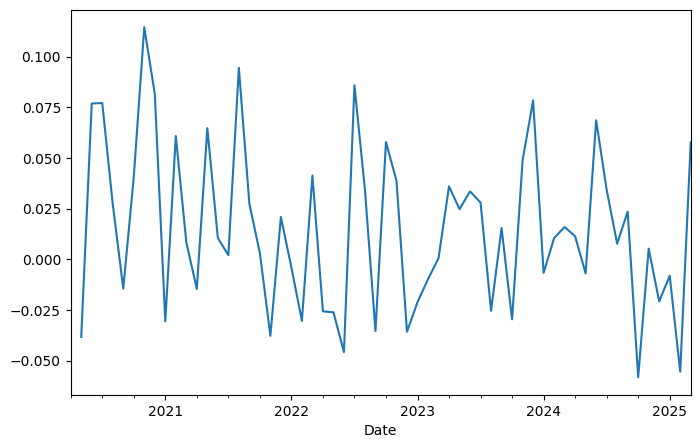

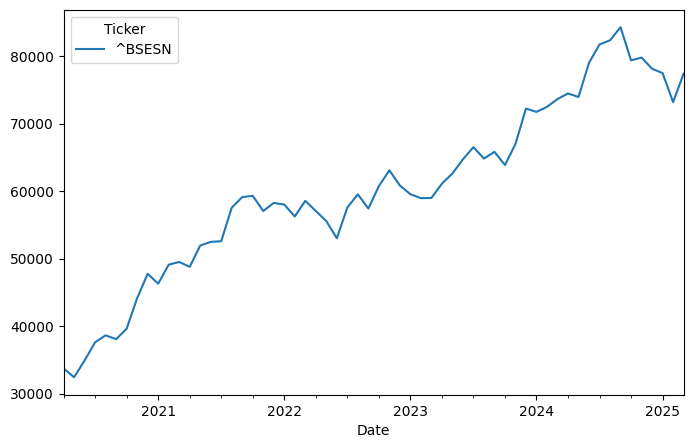

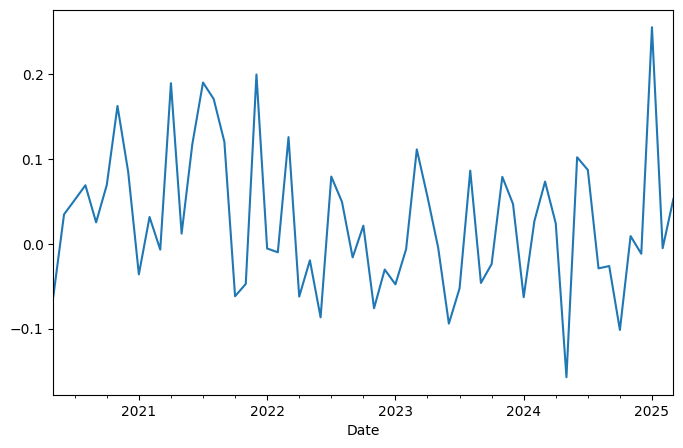

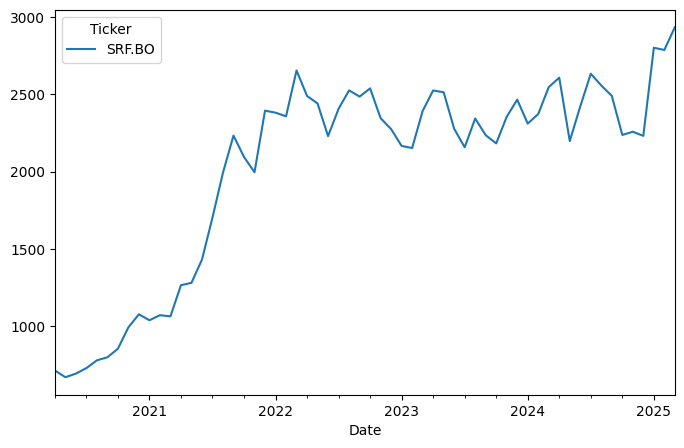

Average returns for market: 0.014992932271670966


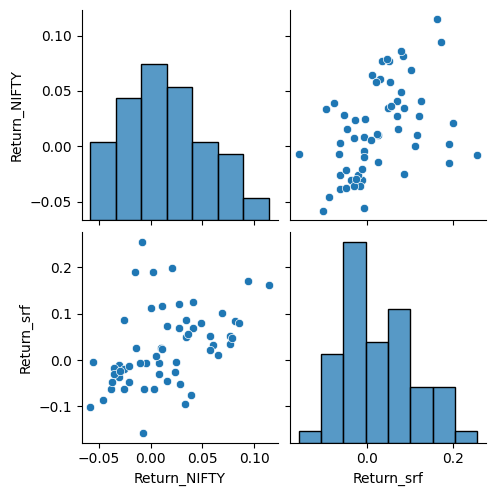

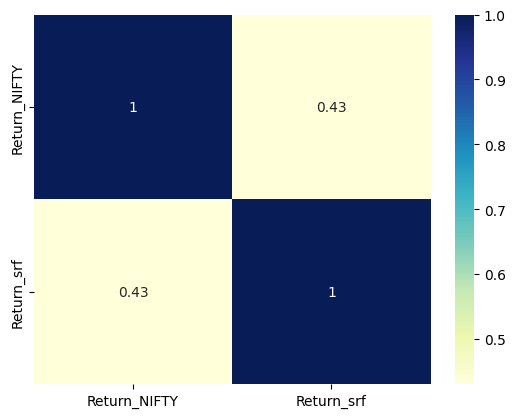

                            OLS Regression Results                            
Dep. Variable:             Return_srf   R-squared:                       0.185
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     12.94
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           0.000672
Time:                        04:10:06   Log-Likelihood:                 68.853
No. Observations:                  59   AIC:                            -133.7
Df Residuals:                      57   BIC:                            -129.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0144      0.011      1.350   

/tmp/ipython-input-285016622.py:86: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(results.resid)


<Axes: xlabel='Return_NIFTY', ylabel='Return_srf'>

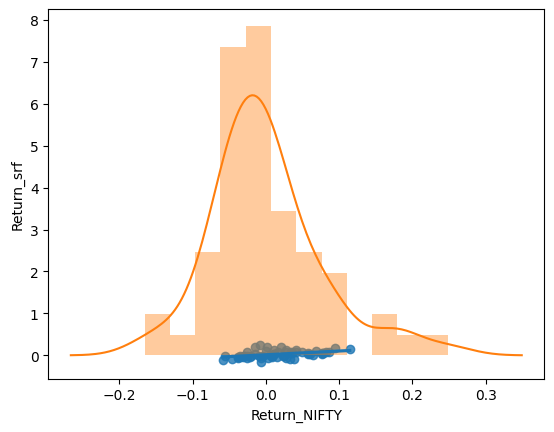

In [ ]:
## GROUP - 37 SRF LTD.

#Calculating the beta using regression


!pip install yfinance
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats

#Download stock prices for the security monthly data last 5 years
srf_df = yf.download('SRF.BO',
                      start='2020-03-31',
                      end='2025-03-31',
                      progress=False,interval ='1mo'
)
srf_df.head()
srf_df.index = srf_df.index.tz_localize(None)

#Download Market index closing prices
nifty_df = yf.download('^BSESN',start='2020-03-31',
                      end='2025-03-31',
                      progress=False,interval ='1mo',
)
nifty_df.head()
nifty_df.index = nifty_df.index.tz_localize(None)

#Calculate returns
nifty_df['Return_NIFTY'] = (nifty_df['Close']-nifty_df['Close'].shift(1))/nifty_df['Close'].shift(1)

nifty_df['Return_NIFTY'].plot(figsize=(8,5))
plt.show()

nifty_df['Close'].plot(figsize=(8,5))
plt.show()

nifty_df1 = nifty_df.dropna(axis=0)
nifty_df1.head()

srf_df['Return_srf'] = (srf_df['Close']-srf_df['Close'].shift(1))/srf_df['Close'].shift(1)


srf_df1 = srf_df.dropna(axis=0)
srf_df1.head()

srf_df1['Return_srf'].plot(figsize=(8,5))
plt.show()

srf_df['Close'].plot(figsize=(8,5))
plt.show()

srf_df1_returns = srf_df1['Return_srf']
srf_df1_returns.head()

nifty_df1_returns = nifty_df1['Return_NIFTY']
nifty_df1_returns.head()
average_value = nifty_df1['Return_NIFTY'].mean()
print('Average returns for market:',average_value)

returns = pd.merge(nifty_df1_returns,srf_df1_returns,how='inner',on='Date')
returns.head()
returns.describe()

sns.pairplot(returns)
plt.show()

sns.heatmap(returns.corr(), annot = True, cmap="YlGnBu")
plt.show()

x = returns['Return_NIFTY']
y = returns['Return_srf']
x_sm = sm.add_constant(x)

model = sm.OLS(y,x_sm)

results=model.fit()
results.summary()
print(results.summary())
returns.info()
sns.regplot(x = 'Return_NIFTY', y = 'Return_srf', data = returns)

sns.distplot(results.resid)